In [ ]:
# Copyright (c) 2026 Nokia Bell Labs
# Licensed under the BSD 3 Clause license
# SPDX-License-Identifier: BSD-3-Clause


## Overview of k-FED

**k-FED** is a federated clustering procedure that operates in two main stages:
1. **Local Clustering at Each Device** (Algorithm&nbsp;1 in the paper):
   Each device (or “client”) runs a local clustering method on its own data (e.g., local k‐means, or the Awasthi–Sheffet k-means variant) to produce one or more “local centers.”
2. **Global Clustering of All Local Centers** (Algorithm&nbsp;2 in the paper):
   The server (or “central node”) collects all these local centers from every device, chooses an initial set of \(k\) global centers, and finally clusters *those centers* into \(k\) groups.

---

## Relation to Algorithm&nbsp;2 (k-FED) from the Paper

Algorithm&nbsp;2 in the paper is summarized as follows:

1. **Local Cluster Centers**:
   “On each device \(z\in [Z]\), run Algorithm&nbsp;1 with local data \(A^{(z)}\) and local cluster count \(k^{(z)}\) to obtain device cluster centers \(\Theta^{(z)}\).”
   - In our code, we *either* run a full local k‐means or (in a simpler case) just compute one local centroid per device (if \(k^{(z)}=1\)).

2. **Collect All Local Centers & Pick an Initial Subset**:
   The server gathers all local centers \(\Theta^{(z)}\). It then picks a device’s centers as a starting set \(M\), and repeatedly adds the center that is *farthest* from the current set \(M\) until \(\lvert M\rvert = k\). This is a standard “farthest‐point” initialization approach.

3. **One Round of Lloyd’s Heuristic**:
   With those \(k\) chosen centers as initial seeds, the algorithm runs a single round of k‐means (Lloyd’s method) on *all* local centers \(\Theta^{(z)}\). This yields a partition into \(k\) clusters \(\tau_1,\dots,\tau_k\).

4. **Output**:
   The final “k-FED induced clustering” is the assignment of each device center \(\Theta^{(z)}\) (and hence indirectly each device point) to one of these \(k\) clusters.

---

## Our Implementation

- **Local Step (Algorithm&nbsp;1):**
  In our code, each device can produce:
  - One local centroid (if \(k' = 1\)), or
  - Multiple local means (if it runs local k-means or Awasthi–Sheffet) on its own data.

- **Global Step (Algorithm&nbsp;2):**
  1. We gather all device centers at the server.
  2. We pick \(k\) initial centers from these (often by a **farthest‐point** approach).
  3. We run **one** iteration of global k-means on these device centers:
     - Either the **standard** k-means update, or
     - The **Awasthi–Sheffet** k-means procedure, if desired.
  4. We assign each device center to the closest global cluster.

- **Why One-Shot**:
  This process requires **only one** communication round: each device sends its local centers, and the server does the final global clustering. There is no back-and-forth iterative update across the network.

Thus, our code faithfully follows :
1. **Collect local centers** → 2. **Pick \(k\) seeds** → 3. **Run a single k-means step** → 4. **Return the global clusters**.


==== delta=0.0003 ====
Standard k-means ARI = -0.028, Awasthi-Sheffet k-means ARI = -0.046
==== delta=0.001 ====
Standard k-means ARI = 0.044, Awasthi-Sheffet k-means ARI = -0.011
==== delta=0.01 ====
Standard k-means ARI = 0.024, Awasthi-Sheffet k-means ARI = 0.170
==== delta=0.02 ====
Standard k-means ARI = 0.023, Awasthi-Sheffet k-means ARI = -0.023
==== delta=0.1 ====
Standard k-means ARI = -0.034, Awasthi-Sheffet k-means ARI = 0.048
==== delta=1.0 ====
Standard k-means ARI = 0.098, Awasthi-Sheffet k-means ARI = 0.269

Plot saved as kfed.pdf/kfed.png in the ../media/ directory.


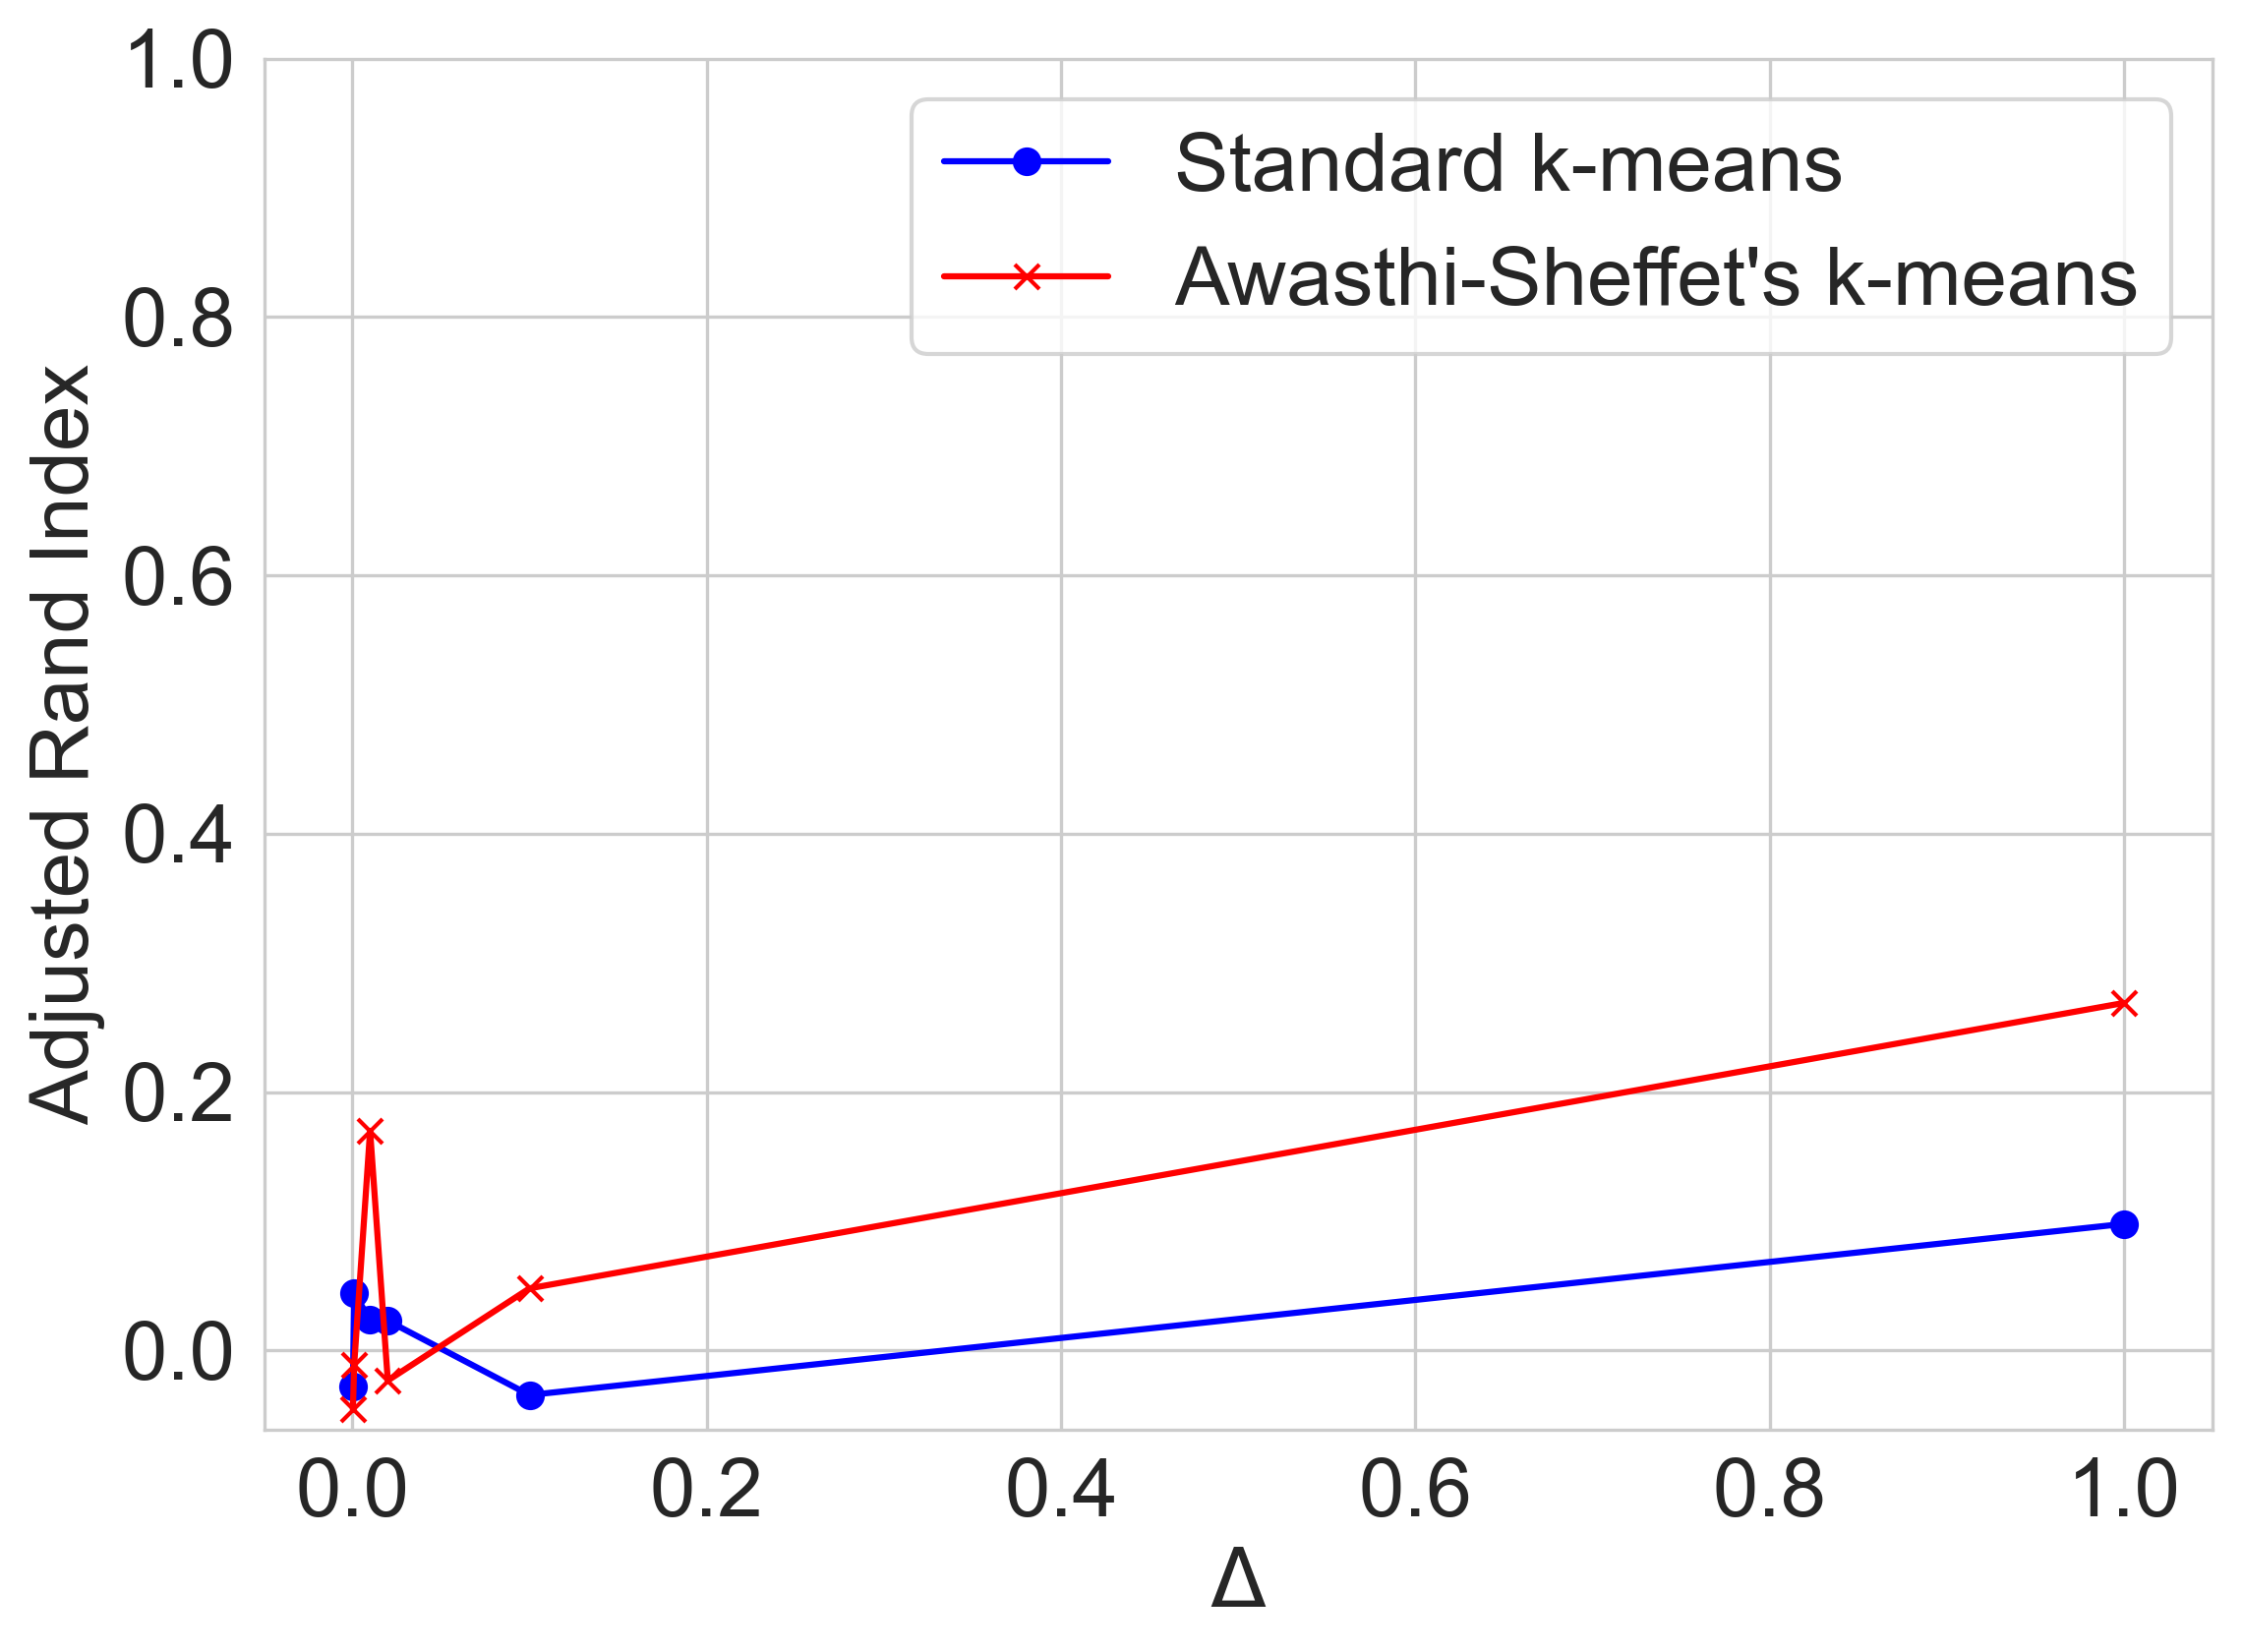

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import scipy
from sklearn.metrics import pairwise_distances as sparse_cdist
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

plt.rcParams['figure.edgecolor'] = 'black'
plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 20


###############################################################################
# (A) EXACT "generate_thetas" function: ensures pairwise dist in [delta, c * delta]
###############################################################################
def generate_thetas(d, n, delta, norm_length, c=5, max_attempts=10000):
    """
    Generates 'n' d-dimensional vectors, each with norm=norm_length,
    ensuring pairwise distances are in [delta, c*delta].
    If not successful within max_attempts, calls sys.exit(1).
    """
    vectors = []

    # Start with a random vector, scaled to norm_length
    x = np.random.randn(d)
    x = (x / np.linalg.norm(x)) * norm_length
    vectors.append(x)

    attempts = 0
    while len(vectors) < n and attempts < max_attempts:
        # Random perturbation of length delta
        y = np.random.randn(d)
        y = (y / np.linalg.norm(y)) * delta

        # Create candidate vector
        x_new = vectors[np.random.randint(len(vectors))] + y
        x_new = x_new / np.linalg.norm(x_new)
        x_new *= norm_length

        # Check pairwise distances
        distances = np.linalg.norm(np.array(vectors) - x_new, axis=1)
        # Must satisfy >= delta and <= c*delta
        if np.all(distances >= delta) and np.all(distances <= c * delta):
            vectors.append(x_new)

        attempts += 1

    if len(vectors) < n:
        print("Could not generate the required thetas within max_attempts")
        sys.exit(1)

    return np.array(vectors)


###############################################################################
# (B) Generate synthetic data in (d+1) using the above generate_thetas
###############################################################################
def generate_linear_dataset(d, K, delta, norm_length, c, sigma, N):
    """
    1) Build K param vectors in R^d using generate_thetas(...)
    2) For each cluster k, sample ~N/K points:
       x ~ N(0,I_d),  y = <x, theta_k> + eps, store [x, y]
    """
    thetas = generate_thetas(d, K, delta, norm_length, c=c)
    cluster_size = N // K
    data_by_cluster = []
    for k in range(K):
        X = np.random.randn(cluster_size, d)
        eps = sigma * np.random.randn(cluster_size)
        y = (X @ thetas[k]) + eps
        data_k = np.hstack([X, y[:, None]])  # shape (cluster_size, d+1)
        data_by_cluster.append(data_k)
    return data_by_cluster


###############################################################################
# (C) Split each cluster's data into M sub-clients, each sampling fraction f
###############################################################################
def split_cluster_into_subclients(data_k, M, f):
    cluster_size = data_k.shape[0]
    sub_size = int(f * cluster_size)
    subclients = []
    for _ in range(M):
        if sub_size > 0:
            idx = np.random.choice(cluster_size, size=sub_size, replace=True)
            sub_data = data_k[idx]
        else:
            sub_data = np.zeros((0, data_k.shape[1]))
        subclients.append(sub_data)
    return subclients

def build_clients_linear(data_by_cluster, M, f):
    data_by_client = []
    labels_by_client = []
    for k, data_k in enumerate(data_by_cluster):
        subs = split_cluster_into_subclients(data_k, M, f)
        data_by_client.extend(subs)
        labels_by_client.extend([k]*len(subs))
    return data_by_client, np.array(labels_by_client)



###############################################################################
# (D) Standard K-Means with farthest-point initialization
###############################################################################
def farthest_point_init(centroids, K):
    Z = len(centroids)
    idx0 = np.random.randint(Z)
    chosen = [centroids[idx0]]
    while len(chosen) < K:
        dist_list = [
            min(np.linalg.norm(c - m) for m in chosen)
            for c in centroids
        ]
        new_idx = np.argmax(dist_list)
        chosen.append(centroids[new_idx])
    return np.array(chosen)

def run_kfed_clustering_standard(centroids, true_labels, K):
    """
    1) Farthest-point init
    2) scikit-learn KMeans(n_init=1)
    3) ARI
    """
    init_centers = farthest_point_init(centroids, K)
    km = KMeans(n_clusters=K, init=init_centers, n_init=1, random_state=42)
    km.fit(centroids)
    preds = km.labels_
    return adjusted_rand_score(true_labels, preds)


###############################################################################
# (E) Awasthi–Sheffet K-Means (code from https://github.com/metastableB/kfed)
###############################################################################
def distance_to_set(A, S, sparse=False):
    if not sparse:
        pd = scipy.spatial.distance.cdist(A, S, metric='euclidean')
    else:
        pd = sparse_cdist(A, S)
    return np.min(pd, axis=1)

def kmeans_pp(A, k, weighted=True, sparse=False):
    n, d = A.shape
    index = np.random.choice(n)
    inits = [A[index]]
    dist_matrix = distance_to_set(A, np.array(inits), sparse=sparse)[:, None]

    while len(inits) < k:
        dx = np.min(dist_matrix, axis=1)
        dx_sq = dx**2
        dx_sq_norm = dx_sq / np.sum(dx_sq)
        if weighted:
            choice = np.random.choice(n, p=dx_sq_norm)
        else:
            choice = np.argmax(dx_sq_norm)
        new_center = A[choice]
        inits.append(new_center)
        dist_new = distance_to_set(A, np.array([new_center]), sparse=sparse)[:, None]
        dist_matrix = np.concatenate([dist_matrix, dist_new], axis=1)
    return np.array(inits)


def awasthisheffet(A, k, useSKLearn=True, sparse=False):
    from sklearn.utils.extmath import randomized_svd
    n, d = A.shape
    if n <= k:
        return A, None

    # 1) SVD => A_hat in R^(n,k)
    U, Sigma, V = randomized_svd(A, n_components=k, random_state=None)
    V = V.T[:, :k]
    A_hat = A.dot(V)

    # 2) k-means++ init in subspace
    inits = kmeans_pp(A_hat, k, sparse=sparse)

    # 3) 1:3 distance split
    pd = scipy.spatial.distance.cdist(inits, A_hat)
    Sr_list = []
    for r in range(k):
        thr = 3.0 * pd[r, :]
        others = pd[np.arange(k) != r]
        indicator = (others - thr) < 0
        indicator = np.sum(indicator.astype(int), axis=0)
        Sr = [i for i in range(len(indicator)) if indicator[i] == 0]
        Sr_list.append(Sr)

    # 4) Lloyd init in subspace
    lloyd_init = []
    for Sr in Sr_list:
        if len(Sr) == 0:
            random_center = np.random.randn(k)
            lloyd_init.append(random_center)
        else:
            lloyd_init.append(np.mean(A_hat[Sr], axis=0))
    lloyd_init = np.array(lloyd_init)
    lloyd_init = lloyd_init.dot(V.T)

    # 5) final KMeans
    if useSKLearn:
        kmeans = KMeans(n_clusters=k, init=lloyd_init, n_init=1, max_iter=300)
        kmeans.fit(A)
        return kmeans.cluster_centers_, kmeans
    else:
        raise NotImplementedError()

def run_kfed_clustering_awa(centroids, true_labels, K):
    _, model = awasthisheffet(centroids, k=K, useSKLearn=True, sparse=False)
    preds = model.labels_
    return adjusted_rand_score(true_labels, preds)


###############################################################################
# (F) Putting it all together, then plotting both lines in one figure
###############################################################################
def compute_subclient_centroids(data_by_client):
    centroids = []
    for dat in data_by_client:
        if len(dat) == 0:
            centroids.append(np.zeros(dat.shape[1], dtype=np.float32))
        else:
            centroids.append(np.mean(dat, axis=0))
    return np.array(centroids)


def main(media_dir):
    np.random.seed(0)

    # === Custom parameters ===
    K = 5                # clusters
    M = 5                # sub-clients per cluster
    cluster_points = 10000  # data points per cluster => total N = K * 1000 = 5000
    N = K * cluster_points
    d = 20
    c = 5
    norm_len = 1.0
    sigma = 0.0001
    f = 0.1  # fraction of cluster data for each sub-client. Each client of a cluster gets f * cluster_points

    # We use multiple delta values in one run
    delta_values = [0.0003, 0.001, 0.01, 0.02, 0.1, 1.0]

    ari_std_list = []
    ari_awa_list = []

    for delta in delta_values:
        print(f"==== delta={delta} ====")
        # 1) generate data
        data_by_cluster = generate_linear_dataset(d, K, delta, norm_len, c, sigma, N)

        # 2) build sub-clients
        data_by_client, labels_by_client = build_clients_linear(data_by_cluster, M, f)

        # 3) compute sub-client centroids
        centroids = compute_subclient_centroids(data_by_client)

        # 4) standard k-means approach
        ari_std = run_kfed_clustering_standard(centroids, labels_by_client, K)

        # 5) awasthisheffet approach
        ari_awa = run_kfed_clustering_awa(centroids, labels_by_client, K)

        ari_std_list.append(ari_std)
        ari_awa_list.append(ari_awa)

        print(f"Standard k-means ARI = {ari_std:.3f}, Awasthi-Sheffet k-means ARI = {ari_awa:.3f}")

    # Plot both lines on a single figure
    plt.figure()
    plt.plot(delta_values, ari_std_list, marker='o', color='blue', label='Standard k-means')
    plt.plot(delta_values, ari_awa_list, marker='x', color='red', label="Awasthi-Sheffet's k-means")
    # plt.title("k-FED: ARI vs. Delta (K=5, 5 clients/cluster, 1000 points/client)")
    plt.ylim(top=1)
    plt.xlabel(r"$\Delta$")
    plt.ylabel("Adjusted Rand Index")
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()

    # Save figure as PDF in current directory
    plot_file = os.path.join(media_dir, "kfed")
    plt.savefig(plot_file + ".pdf", format="pdf")
    plt.savefig(plot_file + ".png", format="png")
    print(f"\nPlot saved as kfed.pdf/kfed.png in the {media_dir} directory.")


if __name__ == "__main__":
    media_dir = "../media/"
    main(media_dir)


Implementing **k-FED** with two clustering methods—**standard k-means** (farthest‐point initialization) and **Awasthi–Sheffet k-means**—and plotting both **Adjusted Rand Index** (ARI) curves as a function of \(\delta\). 


- **Number of clusters \(K=5\)**  
- **Number of sub‐clients per cluster \(M=5\)**  
- **Data points per cluster = 1000** \(\implies\) **total \(N = 5000\)**  
- **Dimension \(d = 20\)**, 
- **\(\sigma = 0.0001\)** noise, 
- **\(c=5\)** for the \(\le c\delta\) distance constraint in `generate_thetas`,  
- **Fraction \(f=1.0\)** so each sub‐client receives the full cluster data (with replacement).


### How It Works

1. **Parameters**:  
   - **`K=5`**: 5 ground‐truth clusters.  
   - **`M=5`**: 5 sub‐clients per cluster.  
   - **`N=5000`**: total data points, i.e. 1000 per cluster.  
   - **`d=20`**, **`c=5`**, **`norm_len=1.0`**, **`sigma=0.0001`**.  
   - **`f=1.0`**: each sub‐client gets the entire cluster’s data with replacement (so all sub‐clients in the same cluster actually see the same 1000 points, though the sampling is still “with replacement” but we draw 1000 of 1000).  

2. **Loop Over \(\delta\)**:  
   We vary \(\delta\in\{0.0003,0.001,0.01,0.02,0.1,1.0\}\). For each \(\delta\):
   1. Generate 5 parameter vectors in \(\mathbb{R}^{20}\) with pairwise distances in \([\delta,5\delta]\) (`c=5`).  
   2. Sample 1000 points for each cluster => total 5000.  
   3. Split each cluster into 5 sub‐clients (which effectively each get 1000 points if `f=1.0`).  
   4. Compute the sub‐client centroids in \(\mathbb{R}^{21}\) (since `d+1=21`).  
   5. Run **standard k-means** (with farthest‐point init) => ARI.  
   6. Run **Awasthi–Sheffet k-means** => ARI.  
   7. Store the two ARI scores.  

3. **Plot**:  
   Finally, we have a single chart with **Delta** on the x‐axis and **ARI** on the y‐axis. We draw **two curves**:
   - Blue circles for the **standard k-means** approach.
   - Red squares for the **Awasthi–Sheffet** approach.  

The resulting PDF named **`kfed.pdf`** is saved to the **current directory**.